In [ ]:
import pandas as pd

df = pd.read_csv("logistic_regression.csv")

df.shape
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [ ]:
df.duplicated().sum()
#duplicate check

np.int64(0)

In [ ]:
(df.isnull().sum() / len(df)) * 100
#missing values percentage

,0
loan_amnt,0.000000
term,0.000000
int_rate,0.000000
installment,0.000000
grade,0.000000
sub_grade,0.000000
emp_title,5.789208
emp_length,4.621115
home_ownership,0.000000
annual_inc,0.000000


Duplicates → 0 (no action)

No column > 30% missing

Moderate missing:

emp_title (6%)

emp_length (4.6%)

mort_acc (9.5%)

#cleaning

In [ ]:
df = df.drop(['emp_title', 'title', 'address'], axis=1)
#Drop columns (not useful / high cardinality)

In [ ]:
df['emp_length'].fillna('Unknown', inplace=True)
df['mort_acc'].fillna(df['mort_acc'].median(), inplace=True)
df['revol_util'].fillna(df['revol_util'].median(), inplace=True)
df['pub_rec_bankruptcies'].fillna(0, inplace=True)
#Handle missing values

/tmp/ipykernel_20695/3916737159.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['emp_length'].fillna('Unknown', inplace=True)
/tmp/ipykernel_20695/3916737159.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [ ]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_length,0
home_ownership,0
annual_inc,0
verification_status,0


In [ ]:
df['emp_length'] = df['emp_length'].fillna('Unknown')
df['mort_acc'] = df['mort_acc'].fillna(df['mort_acc'].median())
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())
df['pub_rec_bankruptcies'] = df['pub_rec_bankruptcies'].fillna(0)

In [ ]:
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,318357
Charged Off,77673


#EDA

In [ ]:
df['loan_status'].value_counts(normalize=True)

,proportion
loan_status,
Fully Paid,0.803871
Charged Off,0.196129


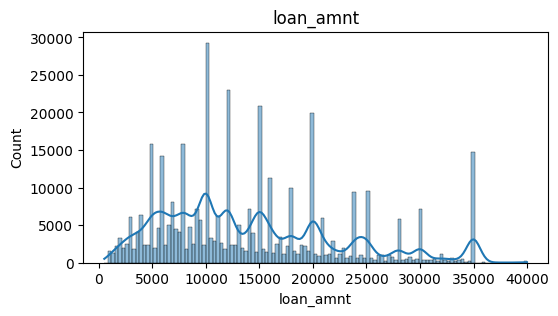

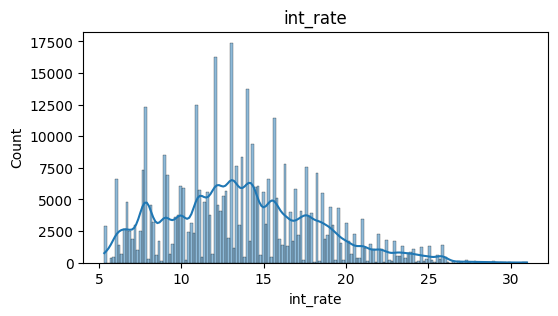

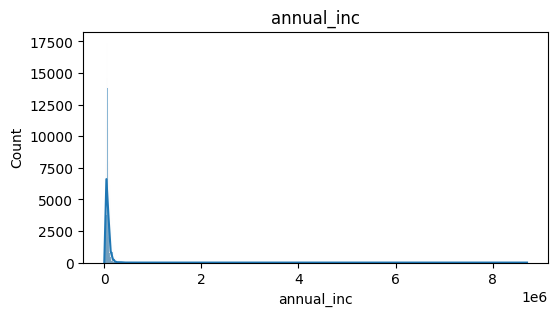

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['loan_amnt', 'int_rate', 'annual_inc']

for col in cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

int_rate: Defaulters (1) have higher interest rates → strong risk indicator

annual_inc: Slightly lower income for defaulters, but weak separation

loan_amnt: No strong difference → loan size alone not decisive

Overall: int_rate is the most influential among these three

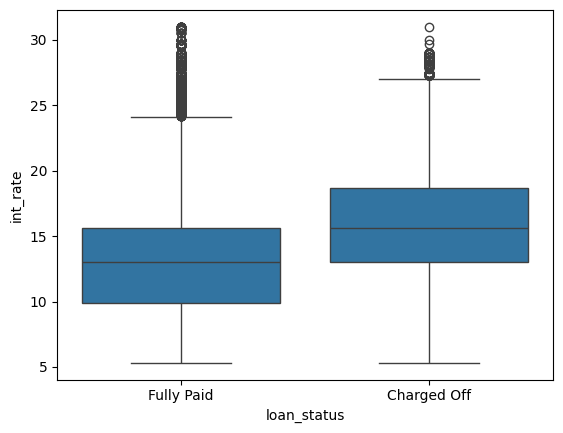

In [ ]:
sns.boxplot(x='loan_status', y='int_rate', data=df)
plt.show()
#loan_status vs int_rate

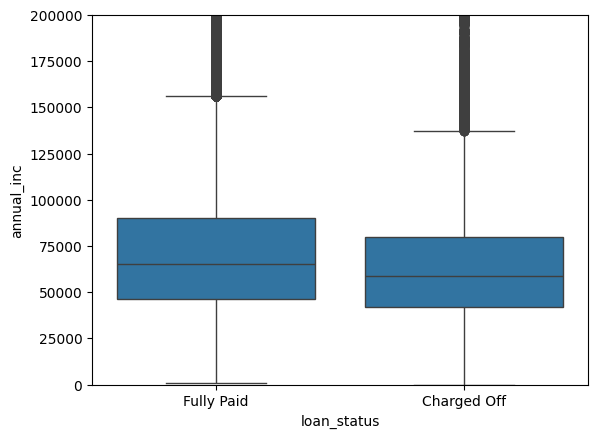

In [ ]:
sns.boxplot(x='loan_status', y='annual_inc', data=df)
plt.ylim(0, 200000)   # limit for visibility
plt.show()
#loan_status vs annual_inc

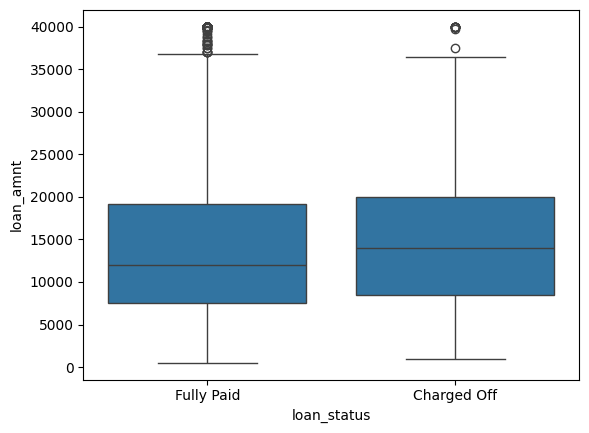

In [ ]:
#loan_status vs loan_amnt
sns.boxplot(x='loan_status', y='loan_amnt', data=df)
plt.show()

int_rate → higher for defaulters → strong predictor

annual_inc → weak separation, heavy overlap

loan_amnt → slight increase for defaulters, not strong

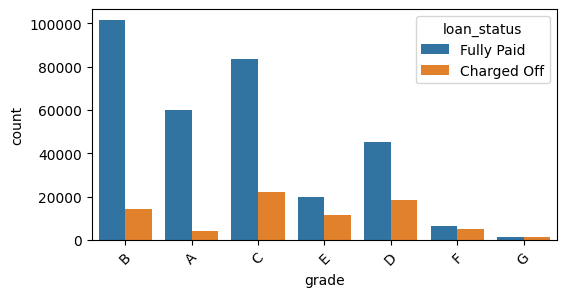

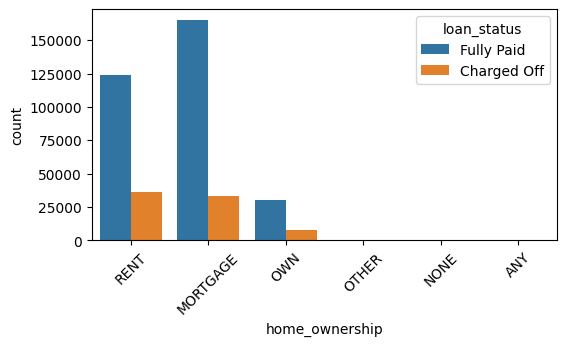

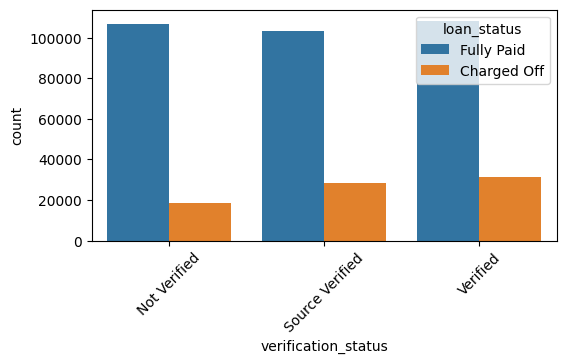

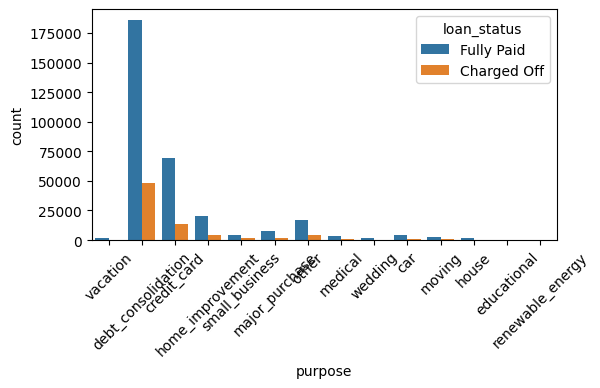

In [ ]:
cat_cols = ['grade', 'home_ownership', 'verification_status', 'purpose']

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, hue='loan_status', data=df)
    plt.xticks(rotation=45)
    plt.show()

grade: lower grade = higher default risk

home_ownership: RENT riskier than MORTGAGE

verification_status:  verified users show slightly higher defaults

purpose: debt_consolidation dominates defaults

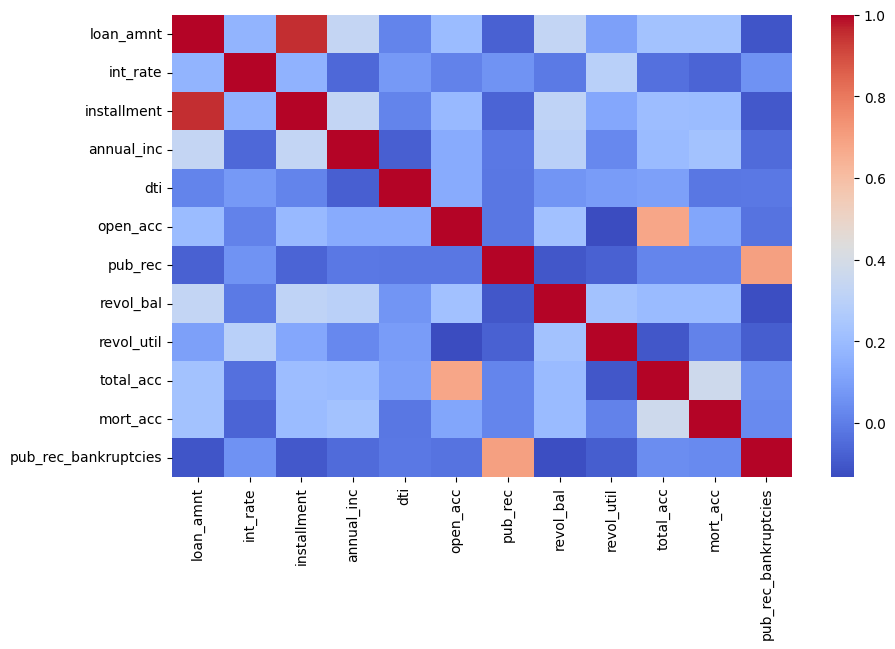

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

* installment is highly correlated with loan_amnt

* open_acc and total_acc show strong relationship

* pub_rec and pub_rec_bankruptcies are strongly related

* most other features show weak correlation

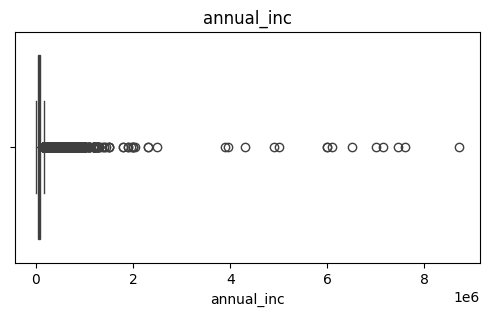

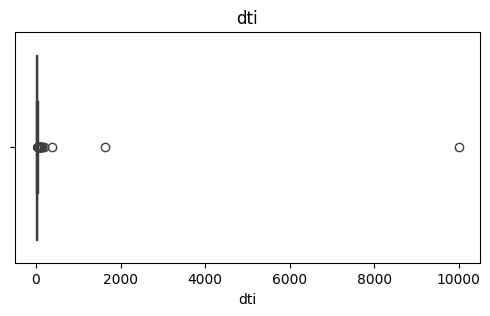

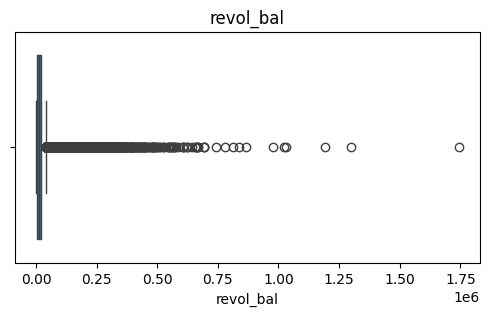

In [ ]:
num_cols = ['annual_inc', 'dti', 'revol_bal']

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

* annual_inc has extreme high-value outliers
* dti contains unrealistic extreme values
* revol_bal shows heavy right-skew with large outliers

In [ ]:
df_original = pd.read_csv("logistic_regression.csv")
df_original['emp_title'].value_counts().head(10)

,count
emp_title,
Teacher,4389
Manager,4250
Registered Nurse,1856
RN,1846
Supervisor,1830
Sales,1638
Project Manager,1505
Owner,1410
Driver,1339


Teacher and Manager are most common

In [ ]:
df['home_ownership'].value_counts(normalize=True)

,proportion
home_ownership,
MORTGAGE,0.500841
RENT,0.403480
OWN,0.095311
OTHER,0.000283
NONE,0.000078
ANY,0.000008


Home ownership:
* Majority is MORTGAGE
* RENT is second highest

#Outlier treatment

In [ ]:
def cap_outliers(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df[col] = df[col].clip(lower, upper)

for col in ['annual_inc', 'dti', 'revol_bal']:
    cap_outliers(col)

#Feature Engineering

In [ ]:
df['term'] = df['term'].str.extract('(\d+)').astype(int)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_20695/3024662541.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['term'] = df['term'].str.extract('(\d+)').astype(int)


In [ ]:
df['emp_length'] = df['emp_length'].str.replace('[^0-9]', '', regex=True)
df['emp_length'] = df['emp_length'].replace('', '0').astype(int)

In [ ]:
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
df['earliest_cr_year'] = df['earliest_cr_line'].dt.year
df.drop('earliest_cr_line', axis=1, inplace=True)

/tmp/ipykernel_20695/763101588.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])


In [ ]:
df['pub_rec_flag'] = df['pub_rec'].apply(lambda x: 1 if x > 0 else 0)
df['mort_acc_flag'] = df['mort_acc'].apply(lambda x: 1 if x > 0 else 0)
df['bankrupt_flag'] = df['pub_rec_bankruptcies'].apply(lambda x: 1 if x > 0 else 0)

#Encoding (categorical to numerical)

In [ ]:
df = df.drop(['grade'], axis=1)
#Drop unnecessary columns

In [ ]:
df = pd.get_dummies(df, drop_first=True)
#one-hot encoding

In [ ]:
df.shape
df.head()

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,dti,open_acc,pub_rec,revol_bal,...,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT
0,10000.0,36,11.44,329.48,10,117000.0,26.24,16.0,0.0,36369.0,...,False,False,False,False,False,True,False,True,True,False
1,8000.0,36,11.99,265.68,4,65000.0,22.05,17.0,0.0,20131.0,...,False,False,False,False,False,False,False,False,True,False
2,15600.0,36,10.49,506.97,1,43057.0,12.79,13.0,0.0,11987.0,...,False,False,False,False,False,False,False,False,True,False
3,7200.0,36,6.49,220.65,6,54000.0,2.60,6.0,0.0,5472.0,...,False,False,False,False,False,False,False,False,True,False
4,24375.0,60,17.27,609.33,9,55000.0,33.95,13.0,0.0,24584.0,...,False,False,False,False,False,False,False,False,True,False


#Scaling

In [ ]:
[col for col in df.columns if 'loan_status' in col]

['loan_status_Fully Paid']

In [ ]:
#define x and y
y = df['loan_status_Fully Paid']
X = df.drop('loan_status_Fully Paid', axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Model Building (Logistic Regression)

In [ ]:
#Train model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [ ]:
#Coefficients
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coeff_df.head(10)
coeff_df.tail(10)

,Feature,Coefficient
1,term,-0.247109
35,sub_grade_D4,-0.247517
3,installment,-0.249422
27,sub_grade_C1,-0.260142
33,sub_grade_D2,-0.262313
32,sub_grade_D1,-0.269260
31,sub_grade_C5,-0.279982
28,sub_grade_C2,-0.280628
30,sub_grade_C4,-0.285944
29,sub_grade_C3,-0.288022


#Evaluation

In [ ]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.55      0.08      0.14     15577
        True       0.81      0.98      0.89     63629

    accuracy                           0.81     79206
   macro avg       0.68      0.53      0.52     79206
weighted avg       0.76      0.81      0.74     79206



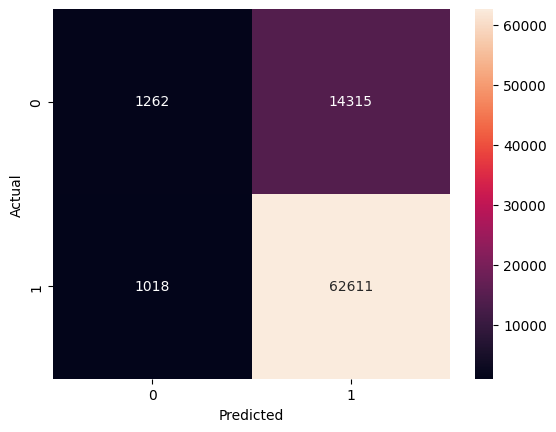

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

* Very high false negatives for defaulters
* Model is biased toward predicting “safe customers”

In [ ]:
#ROC-AUC
from sklearn.metrics import roc_auc_score, roc_curve

roc_auc = roc_auc_score(y_test, y_prob)
roc_auc

np.float64(0.7211738974852935)

Moderate model performance

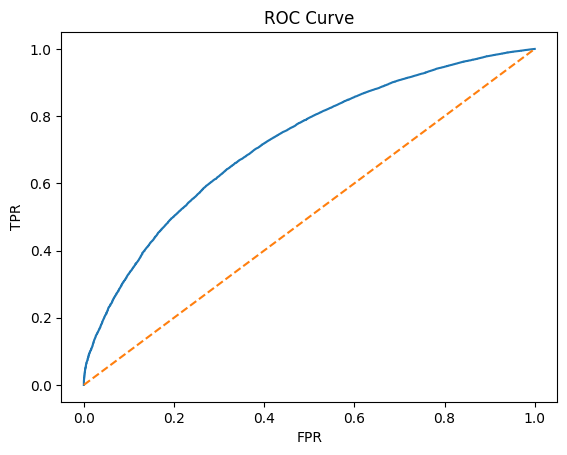

In [ ]:
#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.show()

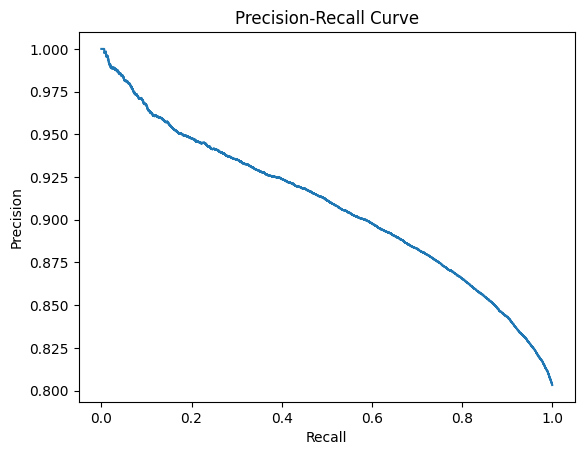

In [ ]:
#Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

Critical Problem:

Model is not catching defaulters

This is dangerous:

Bank will give loans to risky customers
Leads to NPA (bad loans)

Business Interpretation:

Current model is profit-focused (approves too many loans)

But not risk-controlled

Needs tuning to increase recall for defaulters

#Tradeoff Fix

In [ ]:
y_pred_new = (y_prob > 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

       False       0.47      0.00      0.00     15577
        True       0.80      1.00      0.89     63629

    accuracy                           0.80     79206
   macro avg       0.64      0.50      0.45     79206
weighted avg       0.74      0.80      0.72     79206



What happened?:

Lowering threshold didn’t improve defaulter detection

Recall for defaulters still ~0

Model still predicts almost everything as Fully Paid

Root problem:

Class imbalance (80:20)

Model biased toward majority class

Threshold tuning alone won’t fix it

In [ ]:
#Correct Fix
#Use class_weight
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [ ]:
#Evaluate again
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.32      0.68      0.43     15577
        True       0.89      0.64      0.75     63629

    accuracy                           0.65     79206
   macro avg       0.60      0.66      0.59     79206
weighted avg       0.78      0.65      0.68     79206

